# 01 · Your first simulation

Run a stock Gainesville maize treatment and use its results to compare grain yield and follow crop growth.

## You will learn

- Identify treatments and their management levels in a FileX.
- Run one treatment and read grain yield, anthesis date and maturity date.
- Plot daily plant growth and compare grain yield with another treatment.

In [1]:
LESSON = "01_first_simulation"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

Load the tools for reading results and plotting growth.

In [3]:
# Load the lesson tools.
import matplotlib.pyplot as plt
%matplotlib inline
print("Tools ready.")

Tools ready.


Preview the FileX TREATMENTS section to see the management choices.

In [4]:
# Find the treatment header and preview its rows.
filex = RUNS / "UFGA8201.MZX"
lines = filex.read_text(encoding="latin-1").splitlines()
start = next(i for i, line in enumerate(lines) if line.startswith("*TREATMENTS"))
end = next(i for i in range(start + 1, len(lines)) if lines[i].startswith("*"))
print("FileX:", filex.relative_to(HERE).as_posix())
print("\n".join(lines[start:end]).rstrip())

FileX: runs/UFGA8201.MZX
*TREATMENTS                        -------------FACTOR LEVELS------------
@N R O C TNAME.................... CU FL SA IC MP MI MF MR MC MT ME MH SM
 1 1 0 0 RAINFED LOW NITROGEN       1  1  0  1  1  1  1  0  0  0  0  0  1
 2 1 0 0 RAINFED HIGH NITROGEN      1  1  0  1  1  1  2  0  0  0  0  0  1
 3 1 0 0 IRRIGATED LOW NITROGEN     1  1  0  1  1  2  1  0  0  0  0  0  1
 4 1 0 0 IRRIGATED HIGH NITROGEN    1  1  0  1  1  2  2  0  0  0  0  0  1
 5 1 0 0 VEG STRESS LOW NITROGEN    1  1  0  1  1  3  1  0  0  0  0  0  1
 6 1 0 0 VEG STRESS HIGH NITROGEN   1  1  0  1  1  3  2  0  0  0  0  0  1


?? Crop idea: `N` is the treatment number; `MI` = irrigation level and `MF` = fertilizer level.
These six treatments differ only in their irrigation and fertilizer levels.

Run treatment 1 (RAINFED LOW NITROGEN) and show its exit status and run directory.

In [5]:
# Run treatment 1 and locate its results.
result = dl.run(filex, treatment=1)
print("DSSAT exit status:", result.returncode)
print("Run directory:", result.run_dir.relative_to(HERE).as_posix())

DSSAT exit status: 0
Run directory: runs/dssat_run_2026-10-06_200350


List the output file names; next we read `Summary.OUT` and `PlantGro.OUT`.

In [6]:
# List collected output file names compactly.
print(", ".join(path.name for path in result.outputs))

DSSAT48.INH, DSSAT48.INP, ET.OUT, Evaluate.OUT, GHG.OUT, INFO.OUT, LUN.LST, MgmtEvent.OUT, MgmtOps.OUT, Mulch.OUT, N2O.OUT, OUTPUT.LST, OVERVIEW.OUT, PlantGro.OUT, PlantN.OUT, RunList.OUT, SWBalSum.OUT, SoilNBalSum.OUT, SoilNi.OUT, SoilNiBal.OUT, SoilNoBal.OUT, SoilTemp.OUT, SoilWat.OUT, SoilWatBal.OUT, SoilWater.OUT, Summary.OUT, WARNING.OUT, Weather.OUT


Read `Summary.OUT` to display grain yield (`HWAM`, kg/ha), anthesis (`ADAT`) and maturity (`MDAT`).

In [7]:
# Read and display the end-of-season results.
summary = dl.read_summary(result.run_dir)
dl.to_dataframe(summary)[["TRNO", "TNAM", "HWAM", "ADAT", "MDAT"]]

,TRNO,TNAM,HWAM,ADAT,MDAT
0,1,RAINFED LOW NITROGEN,2293,1982-05-13,1982-07-04


?? Python idea: `read_summary()` returns rows; `to_dataframe()` turns them into a table.
Double brackets select columns, and dates appear as calendar dates.

Read `PlantGro.OUT` to preview daily `LAID` (m? leaf/m? ground) and `CWAD` (kg/ha), which are zero before emergence.

In [8]:
# Read and display the first five daily growth rows.
growth = dl.read_plant_growth(result.run_dir)
dl.to_dataframe(growth)[["DATE", "LAID", "CWAD"]].head()

,DATE,LAID,CWAD
0,1982-02-26,0.0,0
1,1982-02-27,0.0,0
2,1982-02-28,0.0,0
3,1982-03-01,0.0,0
4,1982-03-02,0.0,0


Plot leaf area index to follow canopy development over the season.

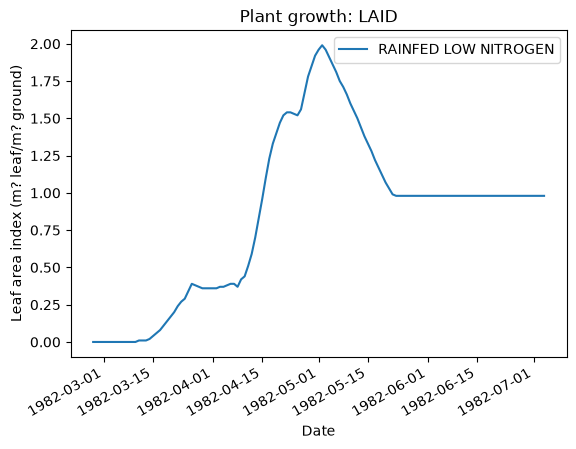

In [9]:
# Plot daily leaf area index with units and readable dates.
ax = dl.plot_plant_growth(result.run_dir, variable="LAID")
ax.set_ylabel("Leaf area index (m? leaf/m? ground)")
ax.figure.autofmt_xdate()
plt.show()

Plot aboveground biomass to follow dry matter accumulation over the season.

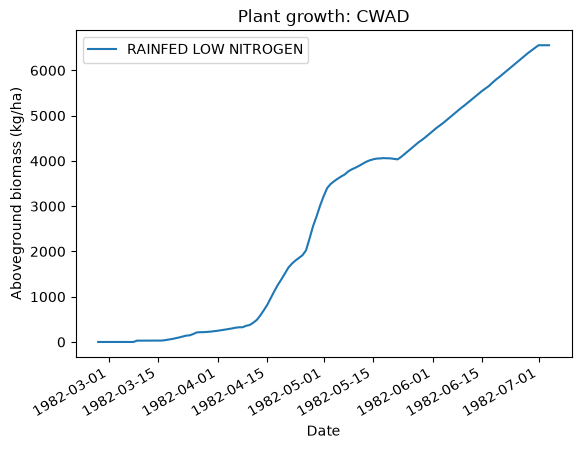

In [10]:
# Plot daily aboveground biomass with units and readable dates.
ax = dl.plot_plant_growth(result.run_dir, variable="CWAD")
ax.set_ylabel("Aboveground biomass (kg/ha)")
ax.figure.autofmt_xdate()
plt.show()

Run treatments 2 and 4 and compare their grain yields with treatment 1.

In [11]:
# Compare rainfed nitrogen levels with irrigated high nitrogen.
comparison_rows = list(summary)
for treatment in (2, 4):
    comparison_result = dl.run(filex, treatment=treatment)
    comparison_rows.extend(dl.read_summary(comparison_result.run_dir))
dl.to_dataframe(comparison_rows)[["TRNO", "TNAM", "HWAM"]]

,TRNO,TNAM,HWAM
0,1,RAINFED LOW NITROGEN,2293
1,2,RAINFED HIGH NITROGEN,2293
2,4,IRRIGATED HIGH NITROGEN,11854


?? Crop idea: Surprisingly, rainfed treatments 1 (low N) and 2 (high N) both yield 2,293 kg/ha because water limited growth in 1982.
Irrigated high-N treatment 4 yields 11,854 kg/ha, an increase of 9,561 kg/ha; extra N alone did not raise grain yield in this simulated season.

## Your turn

Compare treatment 1 with your choice side by side, including the yield difference in kg/ha.

Hint: edit `chosen_treatment = 4` (IRRIGATED HIGH NITROGEN) and run this cell.

In [12]:
# Choose a treatment and rebuild both runs for a yield comparison.
chosen_treatment = 4
comparison_filex = RUNS / "UFGA8201.MZX"
baseline_result = dl.run(comparison_filex, treatment=1)
chosen_result = dl.run(comparison_filex, treatment=chosen_treatment)
baseline_row = dl.read_summary(baseline_result.run_dir)[0]
chosen_row = dl.read_summary(chosen_result.run_dir)[0]
dl.to_dataframe([{
    "Metric": "HWAM (kg/ha)",
    "Baseline: treatment 1": baseline_row["HWAM"],
    f"Choice: treatment {chosen_treatment}": chosen_row["HWAM"],
    "Choice minus baseline": chosen_row["HWAM"] - baseline_row["HWAM"],
}])

,Metric,Baseline: treatment 1,Choice: treatment 4,Choice minus baseline
0,HWAM (kg/ha),2293,11854,9561


## Recap

- A FileX treatment selects the field, cultivar and management levels for its simulation.
- `run()` creates a run directory; `read_summary()` returns yield and development dates.
- Daily growth tables and plots help explain the season, and yield comparisons show management responses.

Next: [02 ? Planting-date sweep](../02_planting_dates/lesson.ipynb).